#### End of distribution Imputation

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('titanic.csv',usecols=['Age','Survived','Fare'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


<Axes: >

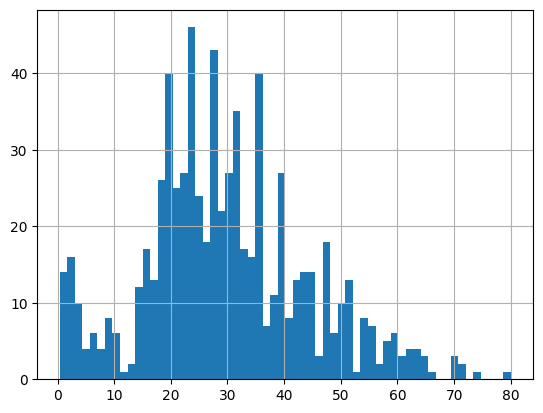

In [8]:
df['Age'].hist(bins=60)

In [18]:
extreme=df.Age.mean() + 3*df.Age.std()
extreme

np.float64(73.27860964406094)

<Axes: xlabel='Age'>

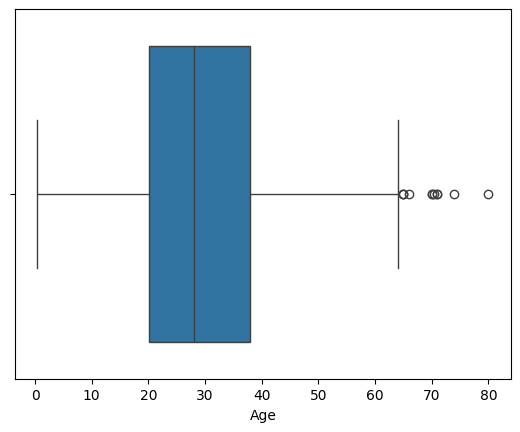

In [17]:
sns.boxplot(data=df,x='Age')

In [19]:
def implace_nan(df,feature,median,extreme): 
    df[feature + '_end_distribution']=df[feature].fillna(extreme)
    df[feature].fillna(median, inplace=True)

In [20]:
implace_nan(df,'Age',df['Age'].median(),extreme)
df.head()

,Survived,Age,Fare,Age_end_distribution
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


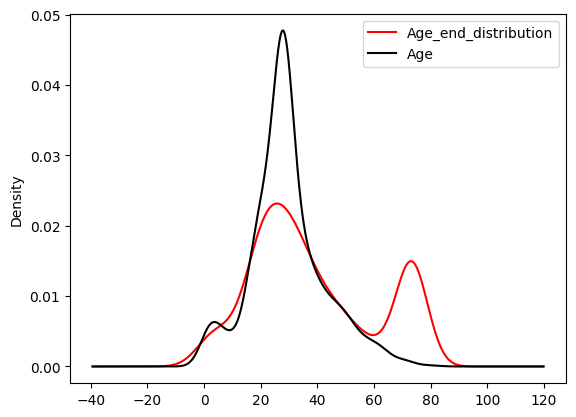

In [29]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['Age_end_distribution'].plot(kind='kde',color='red')
df['Age'].plot(kind='kde',color='black')
lines,label=ax.get_legend_handles_labels()
ax.legend(lines,label)

In [31]:
abs(df['Age_end_distribution'].std()-df['Age'].std())

np.float64(8.699454126163193)

<Axes: >

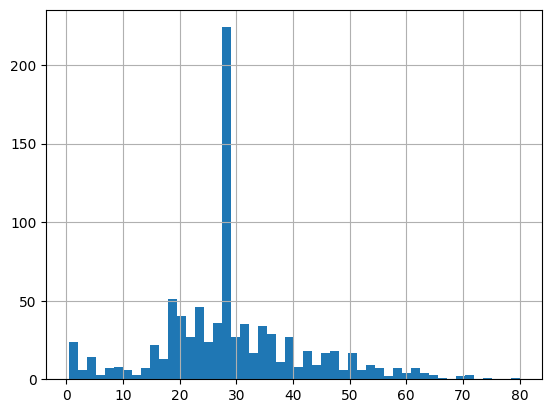

In [32]:
# visualize using histogram
df['Age'].hist(bins=50)

<Axes: >

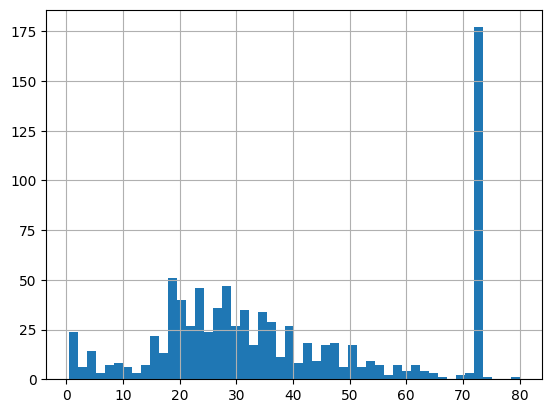

In [33]:
df['Age_end_distribution'].hist(bins=50)

<Axes: xlabel='Age'>

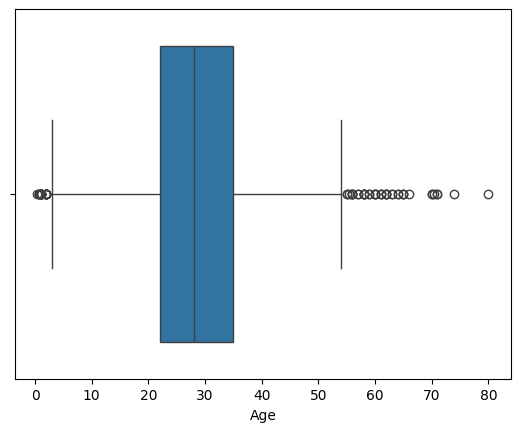

In [34]:
sns.boxplot(data=df,x='Age')   #lots of outliers

<Axes: xlabel='Age_end_distribution'>

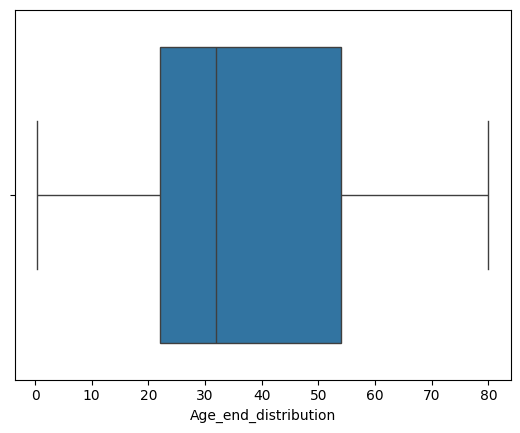

In [35]:
sns.boxplot(data=df,x='Age_end_distribution')    # no outliers

#### Advantage 
1. easy to implement.
2. capture hte importance of missing value.

#### disadvantage:
1. distorts the distribution.
2. if missingess  is not important, it may mask the preductive power of orginal variable by disstorting its distribution.
3. if numbe rof nan value are more, then it mask true outliers.
4. if number of NaN is small, the replaced NaN may be considered as outliers.